# Import Libaries

In [94]:
import kagglehub
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import random
import matplotlib.patches as patches
import shutil
import yaml

from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
from IPython.display import Image, display
from PIL import Image

# 0. Load Data

In [45]:
path = kagglehub.dataset_download(
    "andrewmvd/road-sign-detection",
    output_dir="data"
)

DATA_DIR = Path("data")

IMAGE_DIR = DATA_DIR / "images"
ANNOTATION_DIR = DATA_DIR / "annotations"

print(f"Images path: {IMAGE_DIR}")
print(f"Annotation path: {ANNOTATION_DIR}")

Images path: data\images
Annotation path: data\annotations


# 1. Basic Data Inspection

In [46]:
print("="*50)
print("DATA INSPECTION")
print("="*50)

print("\nNumber of images:")
print("Images:", len(list(IMAGE_DIR.glob("*"))))
print("Annotations:", len(list(ANNOTATION_DIR.glob("*.xml"))))

image_files = [file for file in IMAGE_DIR.iterdir()]
xml_files = list(ANNOTATION_DIR.glob("*.xml"))

# Steam => file without sufix (e.g. .jpg or .xml)
image_stems = {file.stem for file in image_files}
annotation_stems = {file.stem for file in xml_files}

images_without_annotations = image_stems - annotation_stems
annotations_without_images = annotation_stems - image_stems

print("\nFile compatibility:")
print("Images without annotations:", len(images_without_annotations))
print("Annotations without images:", len(annotations_without_images))

print("\n" + "=" * 50)
print("INSPECTION COMPLETE")
print("=" * 50)

DATA INSPECTION

Number of images:
Images: 877
Annotations: 877

File compatibility:
Images without annotations: 0
Annotations without images: 0

INSPECTION COMPLETE


# 2. Basic Data Inspection on Annotation Files

## 2.1 Convert .xml files into Data Frame

In [47]:
def parse_annotation(xml_file):

    tree = ET.parse(xml_file)
    root = tree.getroot()

    objects = []

    for obj in root.findall("object"):

        bbox = obj.find("bndbox")

        objects.append({
            "filename": root.find("filename").text,
            "width": int(root.find("size/width").text),
            "height": int(root.find("size/height").text),
            "class": obj.find("name").text,
            "xmin": int(bbox.find("xmin").text),
            "ymin": int(bbox.find("ymin").text),
            "xmax": int(bbox.find("xmax").text),
            "ymax": int(bbox.find("ymax").text)
        })

    return objects


records = []

for xml_file in xml_files:
    records.extend(parse_annotation(xml_file))


annotations_df = pd.DataFrame(records)

In [48]:
annotations_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,road0.png,267,400,trafficlight,98,62,208,232
1,road1.png,400,283,trafficlight,154,63,258,281
2,road10.png,400,267,trafficlight,106,3,244,263
3,road100.png,400,385,speedlimit,35,5,363,326
4,road101.png,400,200,speedlimit,195,7,392,194


## 2.2 Data Inspection on Annotation Data Frame

In [49]:
print("="*50)
print("ANNOTATIONS DF")
print("="*50)

print("\nNumber of rows:", annotations_df.shape[0])
print("Number of columns:", annotations_df.shape[1])

print("\nColumns:")
for column, dtype in annotations_df.dtypes.items():
    print(f"- {column}: {dtype}")

print("\nMissing values:")
missing_values = annotations_df.isnull().sum()

if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No null values")

print()
print("="*50)
print("INSPECTION COMPLETED")
print("="*50)

ANNOTATIONS DF

Number of rows: 1244
Number of columns: 8

Columns:
- filename: str
- width: int64
- height: int64
- class: str
- xmin: int64
- ymin: int64
- xmax: int64
- ymax: int64

Missing values:
No null values

INSPECTION COMPLETED


### Observation
The XML annotations were successfully parsed into a structured DataFrame containing **1,244 annotated objects** and **8 features**. No missing values were detected, indicating that the annotation data is complete and suitable for further exploratory analysis and conversion to the YOLO format.

# 3. Evaluate Data Analysis
- class distribution
- objects per image
- number of valid bounding boxes

## 3.1 Class Distribution

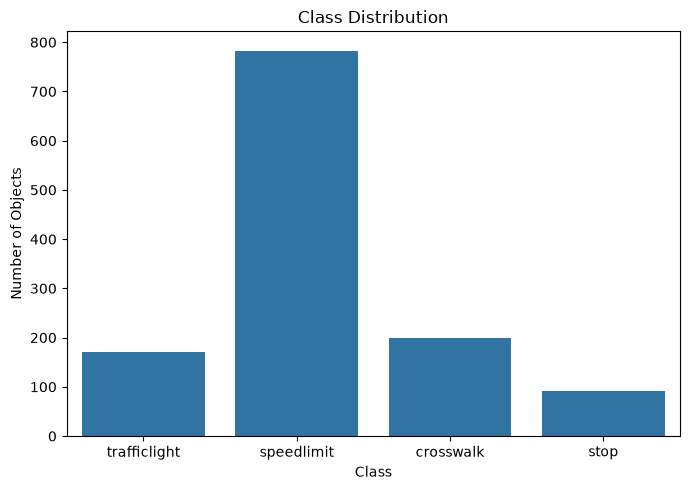

In [50]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=annotations_df,
    x="class"
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.show()

### Observation
The classes are not evenly distributed. The `speedlimit` class contains almost **800 objects**, while `stop`, `crosswalk`, and `trafficlight` contain approximately **100–200 objects** each. This indicates a significant class imbalance in the dataset, which may affect the model's ability to detect less represented classes.

## 3.2 Objects per Image

In [51]:
objects_per_image = annotations_df.groupby("filename").size()

print(objects_per_image.describe())

count    877.000000
mean       1.418472
std        0.828585
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        8.000000
dtype: float64


### Observation
Most images contain a small number of annotated objects. The average is approximately **1.42 objects per image**, while the median is **1 object per image**, meaning that most images contain only one road sign. The maximum number of objects in a single image is **8**. This indicates that the dataset mainly consists of images with a single road sign, with only a smaller number of images containing multiple objects.

## 3.3 Number of Valid Bounding Boxes

In [52]:
invalid_boxes = annotations_df[
    (annotations_df["xmin"] < 0) |
    (annotations_df["ymin"] < 0) |
    (annotations_df["xmax"] > annotations_df["width"]) |
    (annotations_df["ymax"] > annotations_df["height"]) |
    (annotations_df["xmin"] >= annotations_df["xmax"]) |
    (annotations_df["ymin"] >= annotations_df["ymax"])
]

print("Invalid bounding boxes:", len(invalid_boxes))

Invalid bounding boxes: 0


### Info
No invalid bounding boxes were found in the dataset. All bounding box coordinates are within the corresponding image boundaries, and each bounding box has a valid width and height. This indicates that the annotations are structurally consistent and ready for further processing.

# 4. Display Image examples

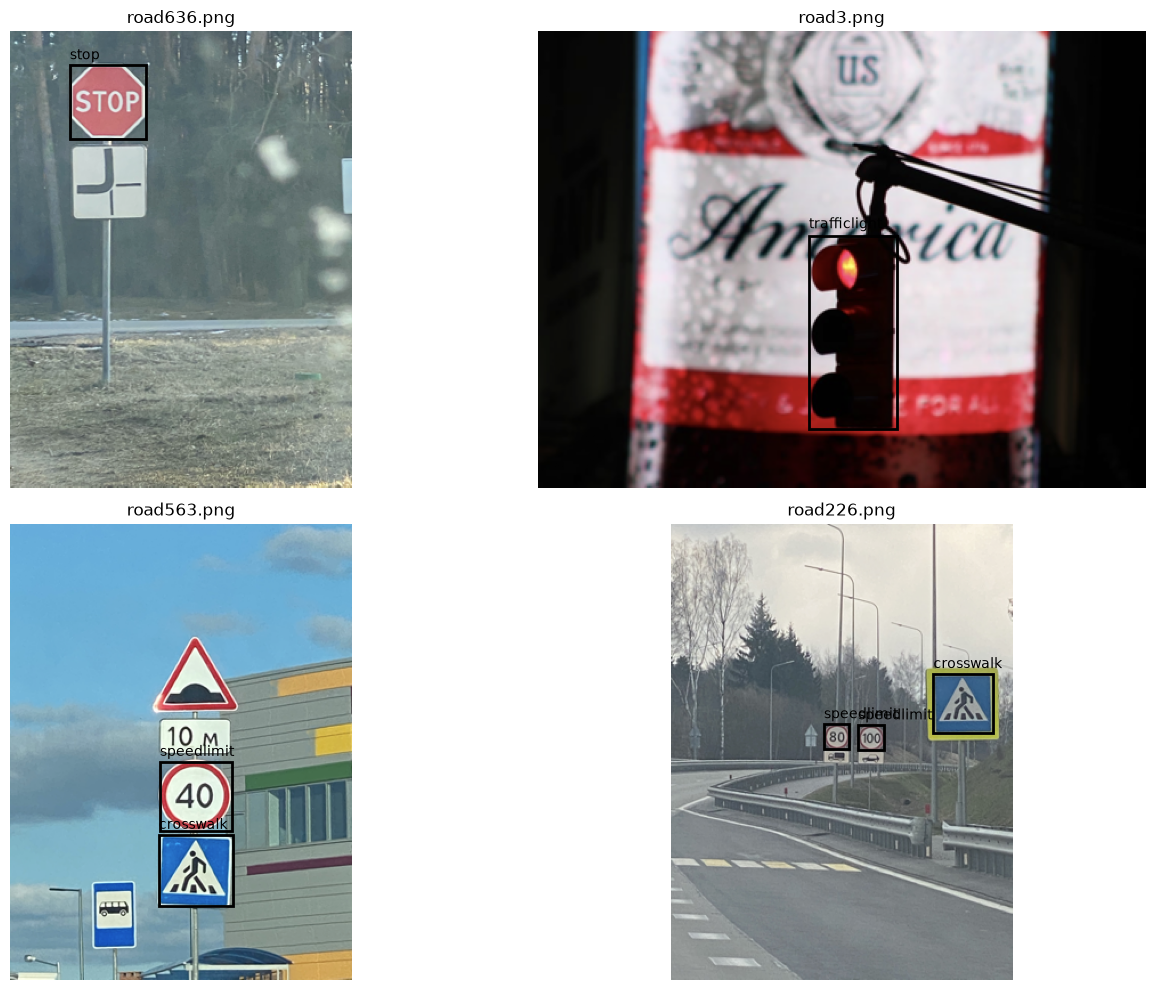

In [53]:
# Get four unique filenames
sample_images = random.sample(
    list(annotations_df["filename"].unique()),
    4
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# Flatten allow us to use one index [0, 1, 2, ...] not [(1, 0), (1, 2), ...]
axes = axes.flatten()

for ax, filename in zip(axes, sample_images):

    image_path = IMAGE_DIR / filename

    image = Image.open(image_path)

    ax.imshow(image)

    image_annotations = annotations_df[
        annotations_df["filename"] == filename
    ]

    for _, row in image_annotations.iterrows():

        rect = patches.Rectangle(
            (row["xmin"], row["ymin"]),
            row["xmax"] - row["xmin"],
            row["ymax"] - row["ymin"],
            linewidth=2,
            fill=False
        )

        ax.add_patch(rect)

        ax.text(
            row["xmin"],
            row["ymin"] - 5,
            row["class"],
            fontsize=10
        )

    ax.set_title(filename)
    ax.axis("off")

plt.tight_layout()
plt.show()

# 5. Data Preprocessing
* Convert XML annotations into YOLO `.txt` format
* Split the dataset into training and validation sets
* Create the `data.yaml` configuration file

## 5.1.1 Map Classes to IDs

In [54]:
classes = sorted(annotations_df["class"].unique())

class_to_id = {
    class_name: class_id
    for class_id, class_name in enumerate(classes)
}

print(class_to_id)

{'crosswalk': 0, 'speedlimit': 1, 'stop': 2, 'trafficlight': 3}


## 5.1.2 Create a Function to Convert XML Bounding Boxes to YOLO Format

In [55]:
def convert_bbox_to_yolo(row, class_to_id):

    image_width = row["width"]
    image_height = row["height"]

    xmin = row["xmin"]
    ymin = row["ymin"]
    xmax = row["xmax"]
    ymax = row["ymax"]

    bbox_width = xmax - xmin
    bbox_height = ymax - ymin

    x_center = (xmax + xmin) / 2
    y_center = (ymax + ymin) / 2

    # Normalize the values
    x_center = x_center / image_width
    y_center = y_center / image_height
    bbox_width = bbox_width / image_width
    bbox_height = bbox_height / image_height

    class_id = class_to_id[row["class"]]

    return (
        class_id,
        x_center,
        y_center,
        bbox_width,
        bbox_height
    )

yolo_bbox = convert_bbox_to_yolo(
    annotations_df.iloc[0],
    class_to_id=class_to_id
)

yolo_bbox

(3,
 np.float64(0.5730337078651685),
 np.float64(0.3675),
 np.float64(0.41198501872659177),
 np.float64(0.425))

In [56]:
yolo_annotations = []

for _, row in image_annotations.iterrows():

    yolo_bbox = convert_bbox_to_yolo(
        row,
        class_to_id
    )

    yolo_annotations.append(yolo_bbox)

print(yolo_annotations)

[(1, 0.48333333333333334, 0.465, 0.07333333333333333, 0.055), (1, 0.585, 0.4675, 0.07666666666666666, 0.055), (0, 0.8533333333333334, 0.3925, 0.17333333333333334, 0.13)]


In [57]:
LABELS_DIR = Path("data/yolo/labels")
LABELS_DIR.mkdir(parents=True, exist_ok=True)

In [58]:
def create_yolo_label(filename, output_dir):
    
    # Get all annotations belonging to this image
    image_annotations = annotations_df[
        annotations_df["filename"] == filename
    ]

    # Create label filename
    label_filename = Path(filename).stem + ".txt"
    label_path = output_dir / label_filename

    # Open file for writing
    with open(label_path, "w") as file:

        for _, row in image_annotations.iterrows():

            class_id, x_center, y_center, bbox_width, bbox_height = (
                convert_bbox_to_yolo(
                    row,
                    class_to_id
                )
            )

            file.write(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{bbox_width:.6f} "
                f"{bbox_height:.6f}\n"
            )

## 5.1.3 Iterate Over Each File and Save It in the Proper Format

In [59]:
for filename in annotations_df["filename"].unique():

    create_yolo_label(
        filename,
        LABELS_DIR
    )

## 5.1.4 Validate the Results

In [60]:
label_files = list(LABELS_DIR.glob("*.txt"))

print("Number of label files:", len(label_files))

Number of label files: 877


In [61]:
invalid_labels = []

for label_file in label_files:

    lines = label_file.read_text().strip().splitlines()

    for line in lines:

        values = line.split()

        if len(values) != 5:
            invalid_labels.append(label_file.name)
            break

print("Invalid label files:", len(set(invalid_labels)))

Invalid label files: 0


### Info
Everything works fine.

## 5.2 Split the Data and Move them to Appropraite 

In [62]:
train_images, val_images = train_test_split(
    annotations_df["filename"].unique(),
    test_size=0.2,
    random_state=42
)

print("Training images:", len(train_images))
print("Validation images:", len(val_images))

Training images: 701
Validation images: 176


In [63]:
YOLO_DIR = Path("data/yolo")

TRAIN_IMG_DIR = YOLO_DIR / "images/train"
VAL_IMG_DIR = YOLO_DIR / "images/val"

TRAIN_LABELS_DIR = YOLO_DIR / "labels/train"
VAL_LABELS_DIR = YOLO_DIR / "labels/val"

for directory in [
    TRAIN_IMG_DIR,
    VAL_IMG_DIR,
    TRAIN_LABELS_DIR,
    VAL_LABELS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

In [64]:
for filename in train_images:

    source = IMAGE_DIR / filename
    destination = TRAIN_IMG_DIR / filename

    shutil.copy2(source, destination)


for filename in val_images:

    source = IMAGE_DIR / filename
    destination = VAL_IMG_DIR / filename

    shutil.copy2(source, destination)


for filename in train_images:

    label_filename = Path(filename).stem + ".txt"

    source = LABELS_DIR / label_filename
    destination = TRAIN_LABELS_DIR / label_filename

    shutil.copy2(source, destination)


for filename in val_images:

    label_filename = Path(filename).stem + ".txt"

    source = LABELS_DIR / label_filename
    destination = VAL_LABELS_DIR / label_filename

    shutil.copy2(source, destination)


for label_file in LABELS_DIR.glob("*.txt"):
    label_file.unlink()

In [65]:
print("Root labels:", len(list(LABELS_DIR.glob("*.txt"))))
print("Train labels:", len(list(TRAIN_LABELS_DIR.glob("*.txt"))))
print("Val labels:", len(list(VAL_LABELS_DIR.glob("*.txt"))))

Root labels: 0
Train labels: 701
Val labels: 176


### Info
Everything works fine.

## 5.3 Create YAML file

In [66]:
data = {
    "path": str(YOLO_DIR),
    "train": "images/train",
    "val": "images/val",
    "names": {
        class_id: class_name
        for class_name, class_id in class_to_id.items()
    }
}

yaml_path = YOLO_DIR / "data.yaml"

with open(yaml_path, "w") as file:
    yaml.dump(data, file, sort_keys=False)

print(yaml_path.read_text())

path: data\yolo
train: images/train
val: images/val
names:
  0: crosswalk
  1: speedlimit
  2: stop
  3: trafficlight



### Info
Everything works fine.

# 6. Model Training

In [67]:
model = YOLO("yolo26n.pt")

In [68]:
results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    project="runs",
    name="road_sign_detection",
)

Ultralytics 8.4.131  Python-3.13.7 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\yolo\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_sign_detection, nb

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002645E174CC0>
Traceback (most recent call last):
  File "d:\Programming_journey\portfolio\ai\ai-ml-portfolio\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1704, in __del__
    self._shutdown_workers()
  File "d:\Programming_journey\portfolio\ai\ai-ml-portfolio\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1648, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


       1/50      3.12G       0.82      6.297   0.004231         39        640: 100% ━━━━━━━━━━━━ 44/44 5.3it/s 8.3s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 8.2it/s 0.7s0.2s
                   all        176        260    0.00667      0.763      0.269      0.221

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       2/50      3.12G     0.8553       4.89   0.004775         20        640: 100% ━━━━━━━━━━━━ 44/44 6.2it/s 7.1s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 8.0it/s 0.7s0.2s
                   all        176        260       0.67      0.331      0.497      0.384

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       3/50      3.12G     0.8794      3.801   0.005032         33        640: 100% ━━━━━━━━━━━━ 44/44 6.3it/s 7.0s0.2s
                 Class     Images  Instances  

# 7. Display Results

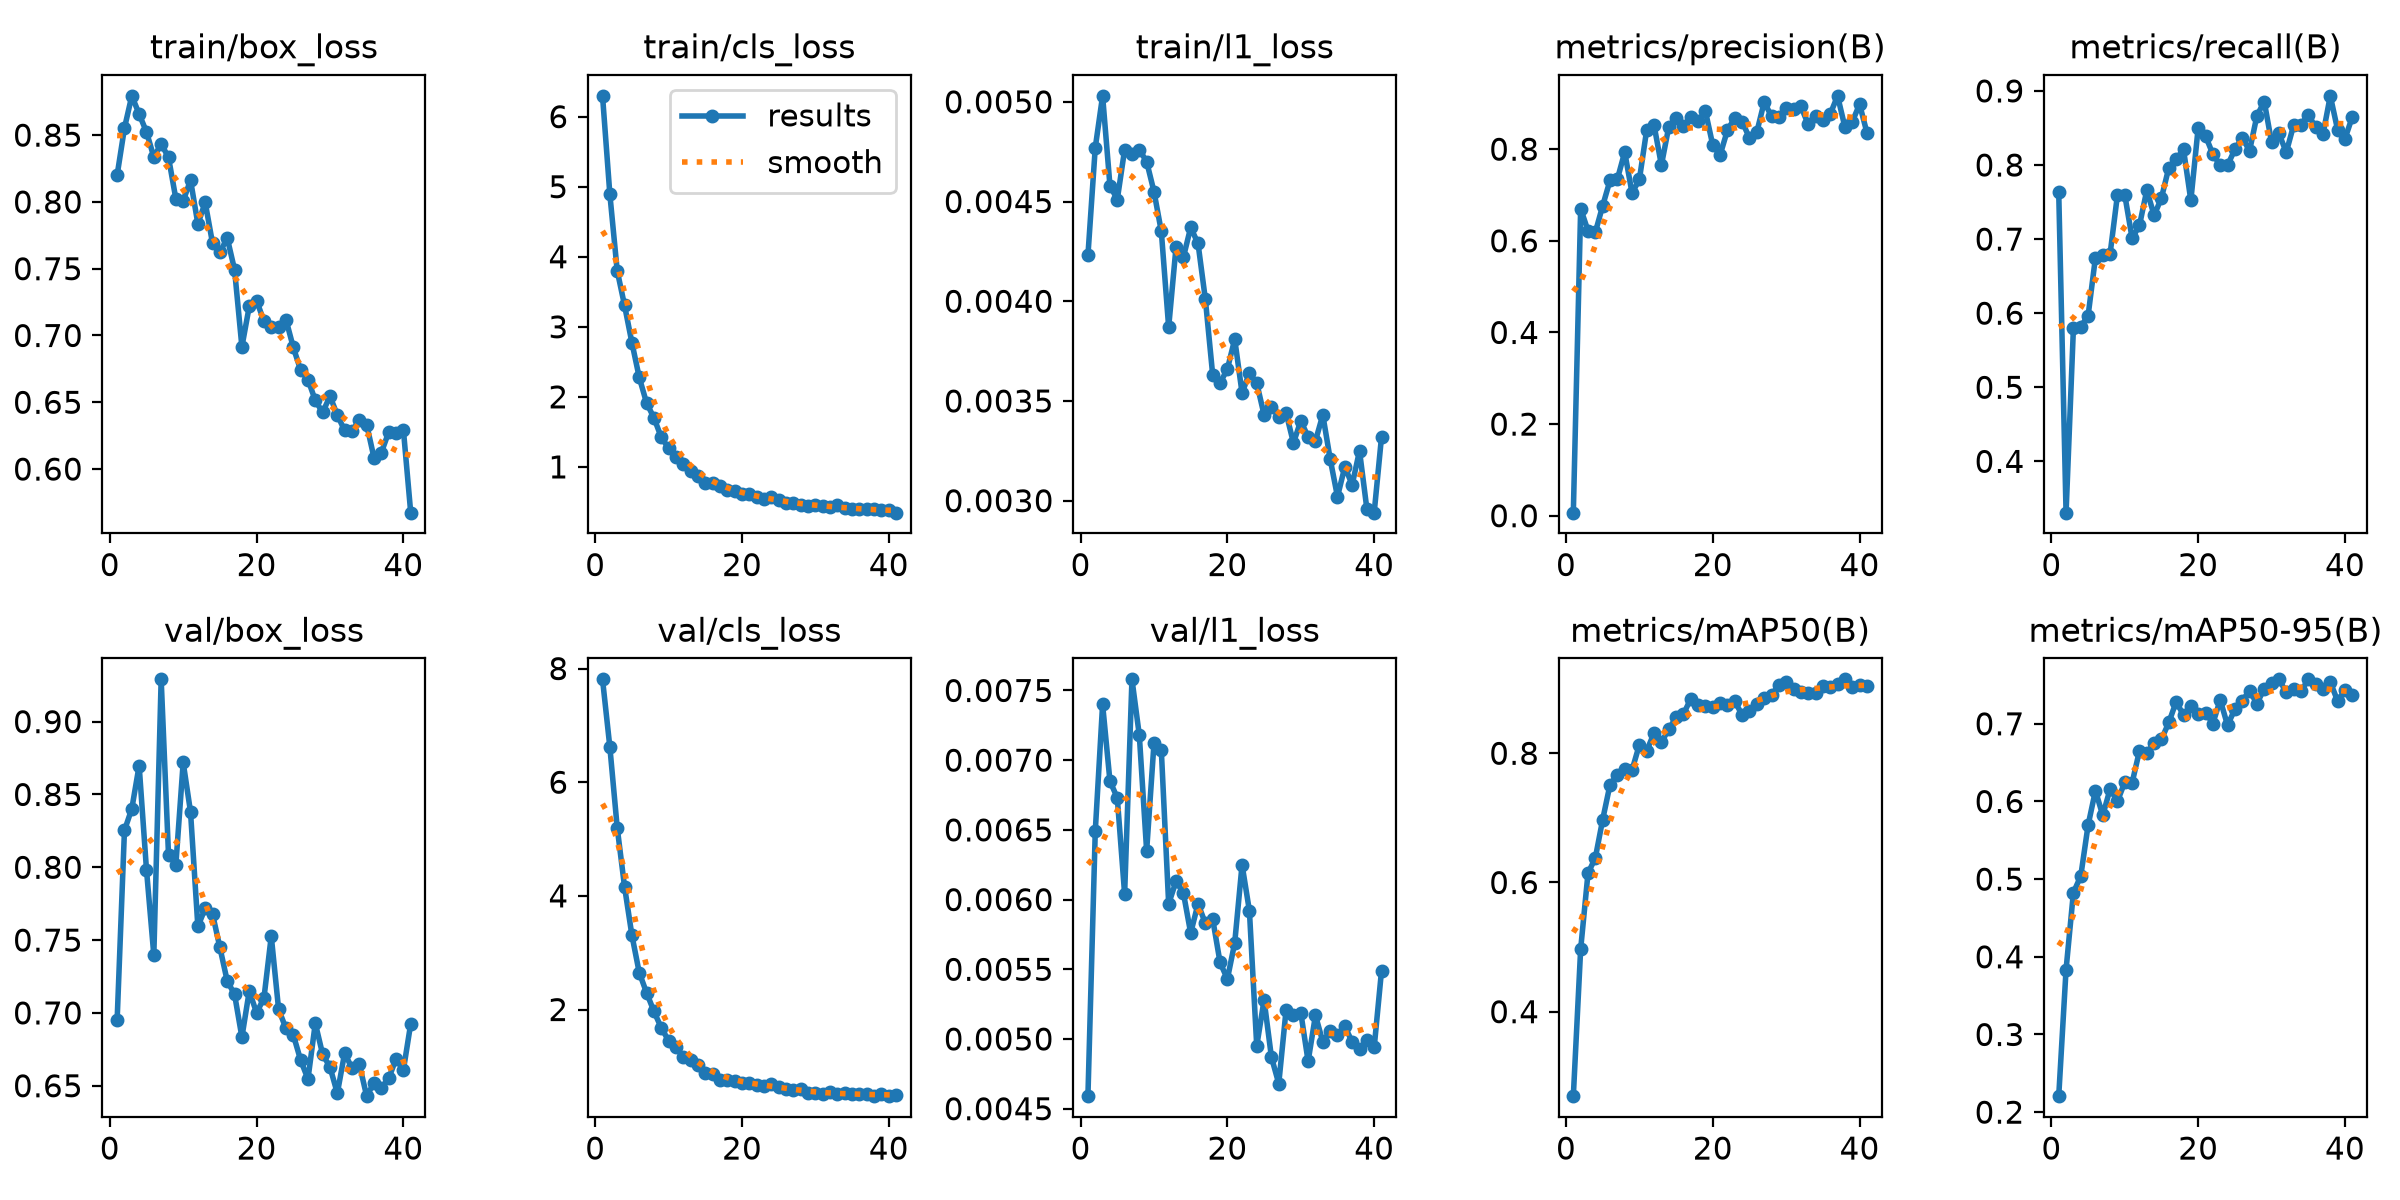

In [76]:
results_path = Path(results.save_dir) / "results.png"

display(Image(filename=str(results_path)))

In [78]:
results_csv = Path(results.save_dir) / "results.csv"

results_df = pd.read_csv(results_csv)

display(results_df.head())

,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
0,1,9.02183,0.82003,6.29738,0.00423,0.00667,0.76308,0.26927,0.22057,0.69494,7.81051,0.00459,0.000407,0.000407,0.000407
1,2,20.72430,0.85530,4.89019,0.00477,0.67015,0.33076,0.49700,0.38359,0.82534,6.61721,0.00649,0.000808,0.000808,0.000808
2,3,32.39110,0.87942,3.80110,0.00503,0.62172,0.57951,0.61430,0.48267,0.84015,5.20205,0.00740,0.001191,0.001191,0.001191
3,4,40.70250,0.86577,3.30572,0.00458,0.61862,0.58197,0.63810,0.50381,0.86981,4.16075,0.00685,0.001176,0.001176,0.001176
4,5,49.00070,0.85238,2.77552,0.00451,0.67646,0.59639,0.69741,0.56940,0.79830,3.30964,0.00673,0.001151,0.001151,0.001151


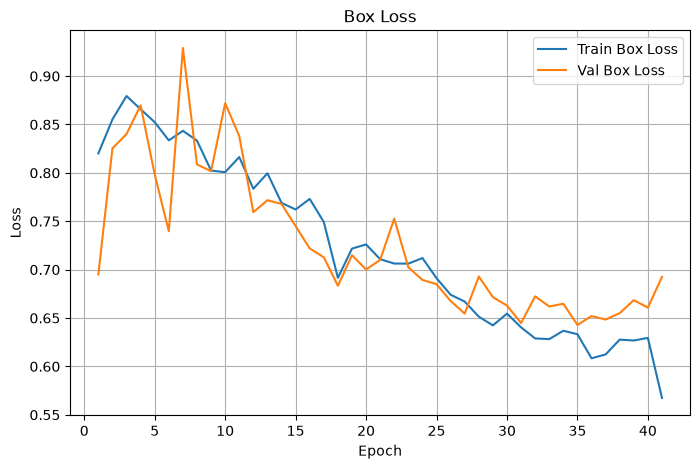

In [79]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["epoch"],
    results_df["train/box_loss"],
    label="Train Box Loss"
)

plt.plot(
    results_df["epoch"],
    results_df["val/box_loss"],
    label="Val Box Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Box Loss")
plt.legend()
plt.grid()

plt.show()

### Observation
The box loss for both the training and validation sets decreased during the first part of training. Around epoch 35, the validation box loss started to increase while the model's performance stopped improving. This may indicate that the model started to overfit the training data, so additional epochs did not provide further improvement on unseen validation data.

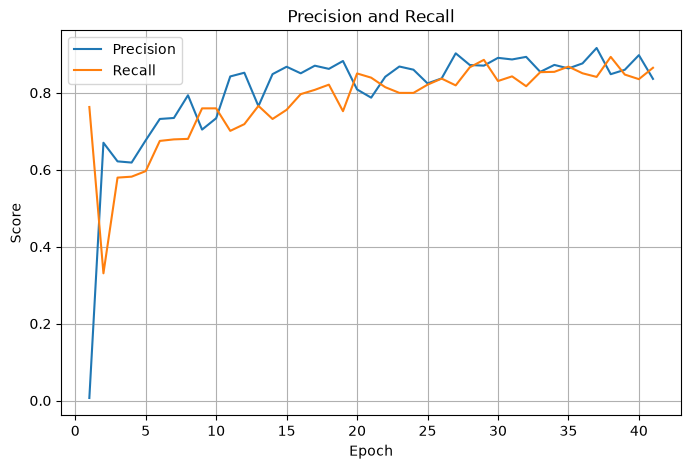

In [80]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["epoch"],
    results_df["metrics/precision(B)"],
    label="Precision"
)

plt.plot(
    results_df["epoch"],
    results_df["metrics/recall(B)"],
    label="Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision and Recall")
plt.legend()
plt.grid()

plt.show()

### Observation
Precision measures how many of the objects predicted by the model are actually correct. A higher precision means that the model produces fewer false positive detections.
Recall measures how many of the actual objects in the images are successfully detected by the model. A higher recall means that the model misses fewer objects.
Both Precision and Recall increase during the first part of training and reach their highest values around epochs 27–28. After that, both metrics fluctuate up and down, indicating that further training does not lead to consistent improvement in the model's detection performance.

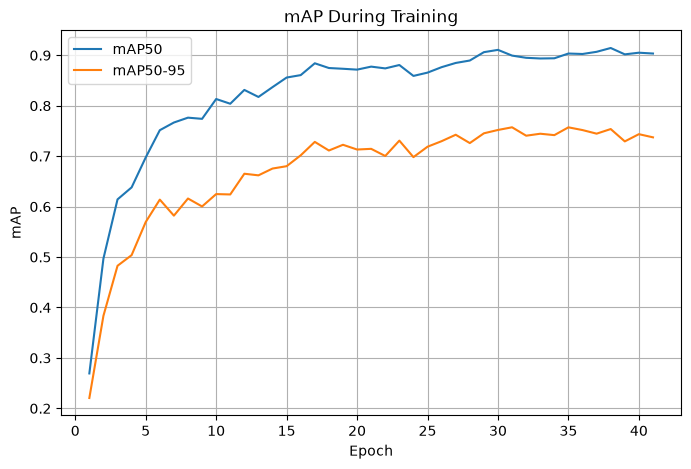

In [81]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["epoch"],
    results_df["metrics/mAP50(B)"],
    label="mAP50"
)

plt.plot(
    results_df["epoch"],
    results_df["metrics/mAP50-95(B)"],
    label="mAP50-95"
)

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP During Training")
plt.legend()
plt.grid()

plt.show()

### Observation
* **mAP50** – shows how well the model detects and recognizes road signs when the predicted bounding box is reasonably close to the actual sign.
* **mAP50-95** – is a stricter version that checks not only whether the model finds the sign, but also how accurately the bounding box fits the sign.

mAP50 and mAP50-95 increase steadily until around epoch 30. After that, both metrics remain relatively stable, indicating that further training does not significantly improve the model's detection or localization performance. The training was eventually stopped early at epoch 41 due to the early stopping mechanism.

# 8. Test the Model on the Validation Images

In [103]:
best_model = YOLO(
    str(Path(results.save_dir) / "weights" / "best.pt")
)

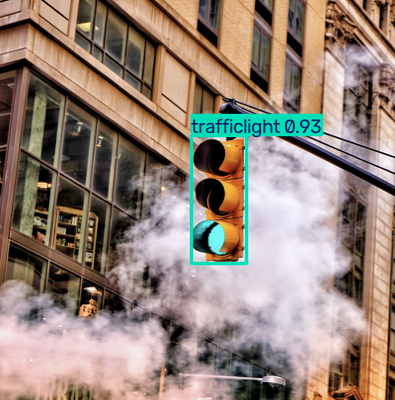

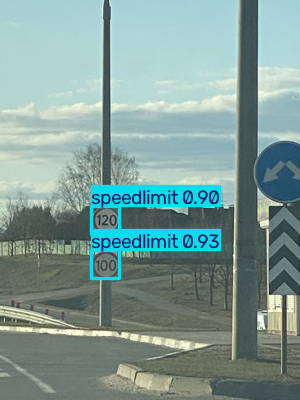

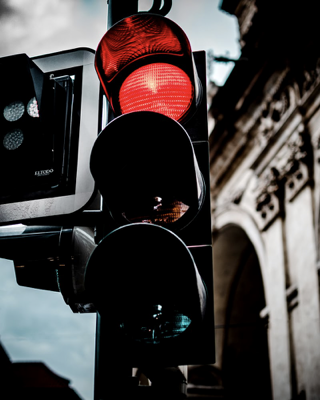

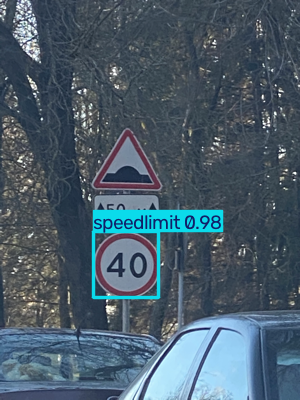

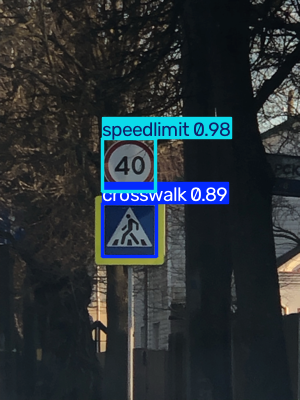

In [115]:
sample_images = random.sample(val_images, 5)

prediction_results = best_model.predict(
    source=[str(image) for image in sample_images],
    conf=0.25,
    verbose=False
)

for result in prediction_results:
    plotted_image = result.plot()
    display(Image.fromarray(plotted_image[..., ::-1]))

### Observation
The model performs quite well on the validation set and correctly detects most of the road signs. However, some signs are still missed, as shown in the third example, where the model does not detect all the visible signs.